<a href="https://colab.research.google.com/github/reddoma742/DTQEM-v5.0-Dual-Time-Quantum-Entanglement-Model-Lindblad-Formulation-/blob/main/dtqem_v5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DTQEM v5.0 - Lindblad thermal model


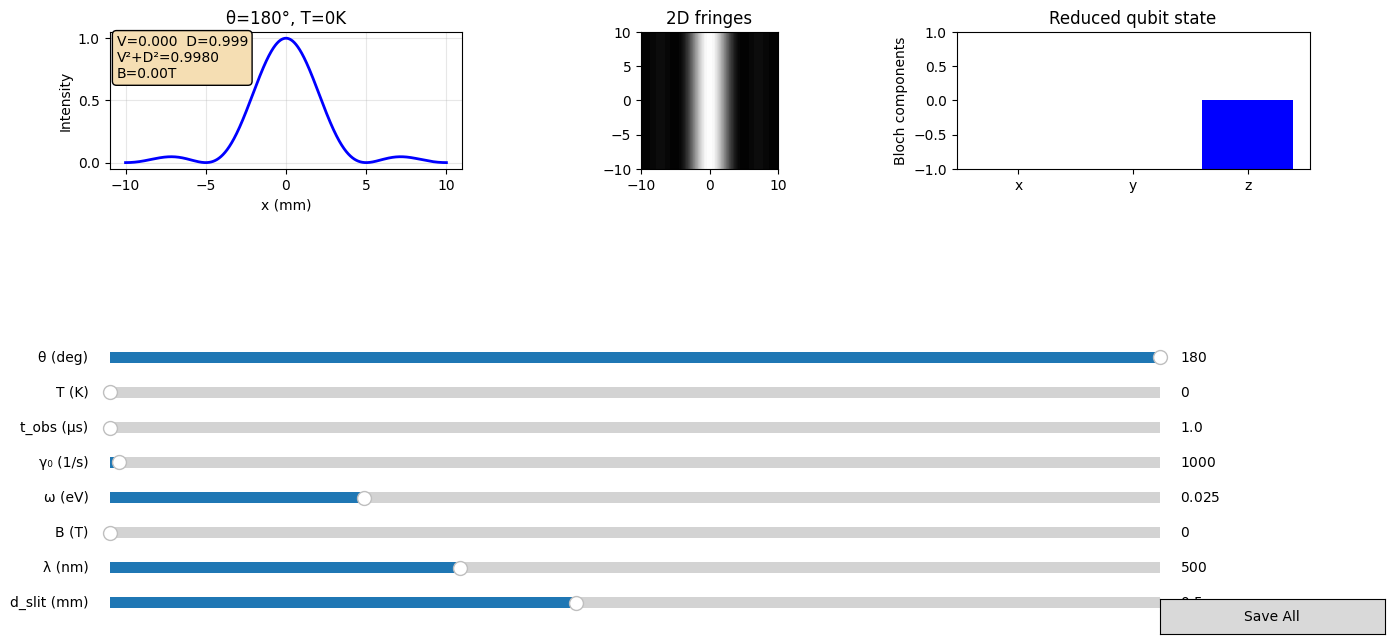

In [1]:

"""
DTQEM v5.0 – Full Lindblad‑thermal model with magnetic field and Bloch vector.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
from scipy.special import sinc
import csv
import os

# ------------------------------------------------------------
# Constants
# ------------------------------------------------------------
class Constants:
    hbar = 1.0545718e-34
    k_B = 1.380649e-23
    eV = 1.60217662e-19

# ------------------------------------------------------------
# Quantum state operations
# ------------------------------------------------------------
class QuantumState:
    @staticmethod
    def entangled_state(theta_deg):
        theta = np.radians(theta_deg)
        c = np.cos(theta/2)
        s = np.sin(theta/2)
        return np.array([c, 0, 0, s], dtype=complex)

    @staticmethod
    def density_matrix(state):
        return np.outer(state, state.conj())

    @staticmethod
    def partial_trace_B(rho_AB):
        rho_A = np.zeros((2,2), dtype=complex)
        rho_A[0,0] = rho_AB[0,0] + rho_AB[1,1]
        rho_A[0,1] = rho_AB[0,2] + rho_AB[1,3]
        rho_A[1,0] = rho_AB[2,0] + rho_AB[3,1]
        rho_A[1,1] = rho_AB[2,2] + rho_AB[3,3]
        return rho_A

    @staticmethod
    def visibility(rho):
        return 2.0 * np.abs(rho[0,3])

    @staticmethod
    def distinguishability(rho):
        rho_A = QuantumState.partial_trace_B(rho)
        return np.abs(np.real(rho_A[0,0] - rho_A[1,1]))

    @staticmethod
    def bloch_vector(rho_A):
        x = 2 * np.real(rho_A[0,1])
        y = 2 * np.imag(rho_A[0,1])
        z = np.real(rho_A[0,0] - rho_A[1,1])
        return x, y, z

    @staticmethod
    def apply_depolarizing_channel(rho, K):
        dim = rho.shape[0]
        identity = np.eye(dim) / dim
        return K * rho + (1 - K) * identity

    @staticmethod
    def lindblad_thermal_rate(T, gamma0, omega_eV):
        if T <= 0:
            return gamma0
        omega = omega_eV * Constants.eV / Constants.hbar
        n_th = 1.0 / (np.exp(Constants.hbar * omega / (Constants.k_B * T)) - 1.0)
        return gamma0 * (2 * n_th + 1)

# ------------------------------------------------------------
# Main DTQEM v5.0 model
# ------------------------------------------------------------
class DTQEM_v5:
    def __init__(self, t_obs=1e-6, gamma0=1000.0, omega_eV=0.025):
        self.t_obs = t_obs
        self.gamma0 = gamma0
        self.omega_eV = omega_eV
        self.B = 0.0

    def set_magnetic_field(self, B):
        self.B = B

    def K_factor(self, T):
        rate = QuantumState.lindblad_thermal_rate(T, self.gamma0, self.omega_eV)
        return np.exp(-rate * self.t_obs)

    def magnetic_phase(self, theta_deg):
        # Simple model for magnetic effect; can be refined to Aharonov‑Bohm
        return np.exp(1j * self.B * 1e-5 * np.sin(np.radians(theta_deg)/2))

    def apply_decoherence_and_field(self, rho, T, theta_deg):
        K = self.K_factor(T)
        rho_dec = QuantumState.apply_depolarizing_channel(rho, K)
        phase = self.magnetic_phase(theta_deg)
        for i in range(4):
            for j in range(4):
                if i != j:
                    rho_dec[i,j] *= phase
        return rho_dec

    def visibility(self, theta_deg, T):
        state = QuantumState.entangled_state(theta_deg)
        rho = QuantumState.density_matrix(state)
        rho_final = self.apply_decoherence_and_field(rho, T, theta_deg)
        return QuantumState.visibility(rho_final)

    def distinguishability(self, theta_deg, T):
        state = QuantumState.entangled_state(theta_deg)
        rho = QuantumState.density_matrix(state)
        rho_final = self.apply_decoherence_and_field(rho, T, theta_deg)
        return QuantumState.distinguishability(rho_final)

    def complementarity(self, theta_deg, T):
        V = self.visibility(theta_deg, T)
        D = self.distinguishability(theta_deg, T)
        return V*V + D*D

    def bloch(self, theta_deg, T):
        state = QuantumState.entangled_state(theta_deg)
        rho = QuantumState.density_matrix(state)
        rho_final = self.apply_decoherence_and_field(rho, T, theta_deg)
        rho_A = QuantumState.partial_trace_B(rho_final)
        return QuantumState.bloch_vector(rho_A)

# ------------------------------------------------------------
# Double‑slit physics (unchanged)
# ------------------------------------------------------------
class DoubleSlit:
    def __init__(self, lam=500e-9, d=0.5e-3, L=1.0, a_slit=0.1e-3):
        self.lam = lam
        self.d = d
        self.L = L
        self.a = a_slit

    def intensity(self, x, V):
        delta = 2*np.pi*self.d*x/(self.lam*self.L)
        beta = np.pi*self.a*x/(self.lam*self.L)
        envelope = sinc(beta/np.pi)**2
        interference = 1 + V*np.cos(delta)
        I = envelope * interference
        if np.max(I) > 0:
            I /= np.max(I)
        return I

    def pattern_1d(self, V, x_range=(-0.01,0.01), points=2000):
        x = np.linspace(x_range[0], x_range[1], points)
        I = self.intensity(x, V)
        return x, I

    def pattern_2d(self, V, xy_range=(-0.01,0.01), res=300):
        x = np.linspace(xy_range[0], xy_range[1], res)
        y = np.linspace(xy_range[0], xy_range[1], res)
        X, Y = np.meshgrid(x, y)
        I_line = self.intensity(x, V)
        I = np.tile(I_line, (res,1))
        return X, Y, I

# ------------------------------------------------------------
# GUI
# ------------------------------------------------------------
class GUI:
    def __init__(self, out_dir="dtqem_outputs_v5"):
        self.out_dir = out_dir
        if not os.path.exists(out_dir):
            os.makedirs(out_dir)
        self.model = DTQEM_v5()
        self.ds = DoubleSlit()
        self.fig = None
        self.ax_int = None
        self.ax_2d = None
        self.ax_bloch = None
        self.sliders = {}
        self.button = None

    def update(self, _):
        theta = self.sliders['theta'].val
        T = self.sliders['T'].val
        t_obs_us = self.sliders['t_obs'].val
        gamma0 = self.sliders['gamma0'].val
        omega = self.sliders['omega'].val
        B = self.sliders['B'].val
        lam_nm = self.sliders['lam'].val
        d_mm = self.sliders['d'].val

        self.model.t_obs = t_obs_us * 1e-6
        self.model.gamma0 = gamma0
        self.model.omega_eV = omega
        self.model.set_magnetic_field(B)
        self.ds.lam = lam_nm * 1e-9
        self.ds.d = d_mm * 1e-3

        V = self.model.visibility(theta, T)
        D = self.model.distinguishability(theta, T)
        comp = self.model.complementarity(theta, T)
        xb, yb, zb = self.model.bloch(theta, T)

        # 1D pattern
        self.ax_int.clear()
        x, I = self.ds.pattern_1d(V)
        self.ax_int.plot(x*1e3, I, 'b-', lw=2)
        self.ax_int.set_xlabel('x (mm)')
        self.ax_int.set_ylabel('Intensity')
        self.ax_int.set_title(f'θ={theta}°, T={T}K')
        self.ax_int.grid(alpha=0.3)
        info = f'V={V:.3f}  D={D:.3f}\nV²+D²={comp:.4f}\nB={B:.2f}T'
        self.ax_int.text(0.02,0.98,info, transform=self.ax_int.transAxes,
                         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))

        # 2D pattern
        self.ax_2d.clear()
        X, Y, I2 = self.ds.pattern_2d(V)
        self.ax_2d.contourf(X*1e3, Y*1e3, I2, levels=50, cmap='gray')
        self.ax_2d.set_aspect('equal')
        self.ax_2d.set_title('2D fringes')

        # Bloch vector bar plot
        self.ax_bloch.clear()
        self.ax_bloch.bar(['x','y','z'], [xb,yb,zb], color=['r','g','b'])
        self.ax_bloch.set_ylim(-1,1)
        self.ax_bloch.set_ylabel('Bloch components')
        self.ax_bloch.set_title('Reduced qubit state')

        self.fig.canvas.draw_idle()

    def save(self, _):
        self.fig.savefig(os.path.join(self.out_dir, 'interactive.png'), dpi=150)
        # Static plots
        T_range = np.linspace(0,300,200)
        angles = [0,90,120,150,180]
        plt.figure()
        for th in angles:
            Vlist = [self.model.visibility(th, Tk) for Tk in T_range]
            plt.plot(T_range, Vlist, label=f'θ={th}°')
        plt.legend(); plt.grid(); plt.savefig(os.path.join(self.out_dir,'visibility_vs_T.png')); plt.close()

        comp180 = [self.model.complementarity(180,Tk) for Tk in T_range]
        plt.figure()
        plt.plot(T_range, comp180); plt.axhline(1,ls='--',color='k'); plt.ylim(0,1.05)
        plt.savefig(os.path.join(self.out_dir,'complementarity.png')); plt.close()

        with open(os.path.join(self.out_dir,'results.csv'),'w',newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['theta','T','V','D','comp'])
            for th in angles:
                for Tk in [0,77,150,300]:
                    V = self.model.visibility(th,Tk)
                    D = self.model.distinguishability(th,Tk)
                    comp = self.model.complementarity(th,Tk)
                    writer.writerow([th,Tk,V,D,comp])
        print(f"Saved to {self.out_dir}")

    def run(self):
        self.fig = plt.figure(figsize=(15,7))
        self.ax_int = plt.subplot2grid((2,3),(0,0),colspan=1)
        self.ax_2d = plt.subplot2grid((2,3),(0,1),colspan=1)
        self.ax_bloch = plt.subplot2grid((2,3),(0,2),colspan=1)
        plt.subplots_adjust(left=0.1, bottom=0.45)

        axes = {}
        ax_theta = plt.axes([0.1,0.40,0.7,0.03])
        ax_T = plt.axes([0.1,0.35,0.7,0.03])
        ax_tobs = plt.axes([0.1,0.30,0.7,0.03])
        ax_gamma0 = plt.axes([0.1,0.25,0.7,0.03])
        ax_omega = plt.axes([0.1,0.20,0.7,0.03])
        ax_B = plt.axes([0.1,0.15,0.7,0.03])
        ax_lam = plt.axes([0.1,0.10,0.7,0.03])
        ax_d = plt.axes([0.1,0.05,0.7,0.03])

        self.sliders['theta'] = Slider(ax_theta, 'θ (deg)', 0,180,valinit=180,valstep=1)
        self.sliders['T'] = Slider(ax_T, 'T (K)', 0,300,valinit=0,valstep=1)
        self.sliders['t_obs'] = Slider(ax_tobs, 't_obs (μs)',0.1,1000,valinit=1,valstep=0.1)
        self.sliders['gamma0'] = Slider(ax_gamma0, 'γ₀ (1/s)', 100, 1e5, valinit=1000,valstep=100)
        self.sliders['omega'] = Slider(ax_omega, 'ω (eV)',0.001,0.1,valinit=0.025,valstep=0.001)
        self.sliders['B'] = Slider(ax_B, 'B (T)',0,10,valinit=0,valstep=0.1)
        self.sliders['lam'] = Slider(ax_lam, 'λ (nm)',400,700,valinit=500,valstep=1)
        self.sliders['d'] = Slider(ax_d, 'd_slit (mm)',0.1,1.0,valinit=0.5,valstep=0.01)

        for s in self.sliders.values():
            s.on_changed(self.update)

        ax_button = plt.axes([0.8,0.02,0.15,0.05])
        self.button = Button(ax_button, 'Save All')
        self.button.on_clicked(self.save)

        self.update(None)
        plt.show()

if __name__ == "__main__":
    print("DTQEM v5.0 - Lindblad thermal model")
    gui = GUI()
    gui.run()